In [1]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

Solving Prothero-Robinson by using GLEE-i2a with fixed dt=0.01


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


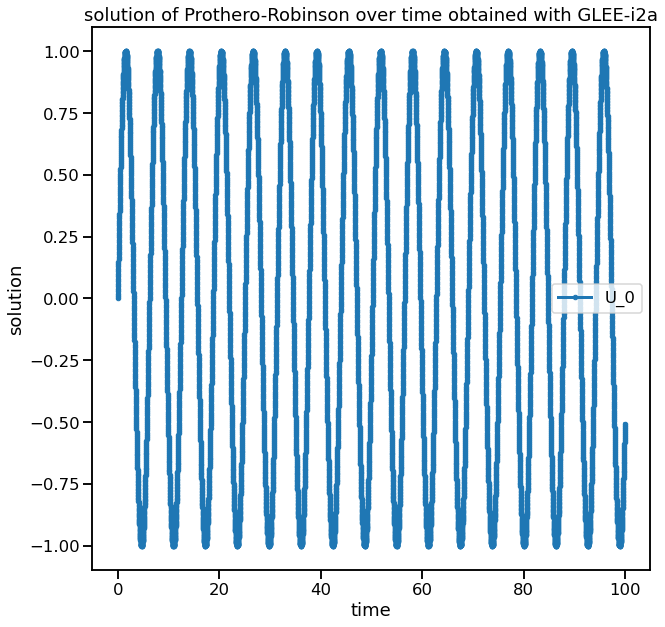

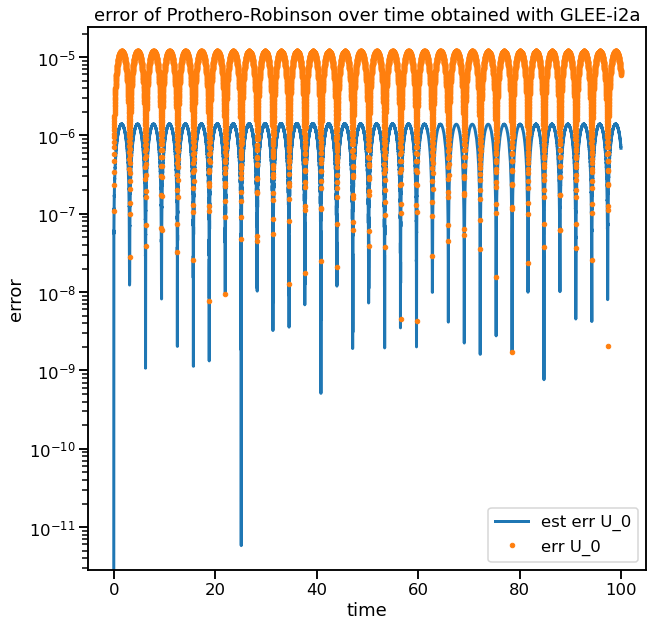

In [2]:
solver=DESolver()
solver.set_info(0)
#rhs_e, rhs_i, u_ini, problem_setup, problem = ProblemsODE('Kulikov-III')
rhs_e, rhs_i, u_ini, problem_setup, problem = ProblemsODE('Prothero-Robinson')
solver.setup()
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)
solver.set_method('GLEE-i2a')

if(rhs_i is not None):
    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
else:
    solver.set_rhs(rhs_e)
    
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:} with fixed dt={:}'.format(problem_setup['name'],
                                                          solver.get_method_name(),
                                                          problem_setup['DT']))

solver.solve()

t,u,glee,_,_=solver.get_trajectory_GLEE()

u_exact=problem.exact_solution(t,problem_setup['context'])


fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.plot(t,u[i,:],'.-', lw=3, label = 'U_{:}'.format(i))
plt.ylabel('solution')
plt.xlabel('time')
plt.legend()
plt.title('solution of {:} over time obtained with {:}'.format(problem_setup['name'],solver.get_method_name()))
plt.show()

fig = plt.figure(figsize=(10, 10))
for i in range(u.shape[0]):
    plt.semilogy(t,np.abs(glee[i,:]),'-', lw=3, label = 'est err U_{:}'.format(i))
    plt.semilogy(t,np.abs(u_exact[i,:]-u[i,:]),'.', lw=3, label = 'err U_{:}'.format(i))
    
plt.ylabel('error')
plt.xlabel('time')
plt.legend()
plt.title('error of {:} over time obtained with {:}'.format(problem_setup['name'],solver.get_method_name()))
plt.show()